## Notebook 7: plink2 GWAS baseline (candidate-gene panel)

A classical-statistics comparison point for the AlphaGenome-based classifiers evaluated in
[`05_evaluation.ipynb`](./05_evaluation.ipynb): does a standard variant-level association test,
run on the exact same cohort/phenotype/candidate genes with real GWAS QC (missingness, HWE,
relatedness, LD-pruning, multiple-testing correction), find the same genes/regions "significant"?
Without this, there's no way to tell whether AlphaGenome is adding real signal over a simple
allele-frequency-difference test.

**Read this caveat before the results below**: this cohort's phenotype (`strong pigmentation` /
`weak pigmentation`, from `notebooks/data/experiment.json`'s `class_map`) is *defined by* 1000
Genomes population membership -- AFR populations (YRI/ESN/LWK/MSL/GWD) = strong, EUR populations
(FIN/CEU/GBR) = weak. That's a pre-existing characteristic of the whole notebook series, not
something new here, but it has a direct consequence for GWAS design: genome-wide ancestry PCs
would be almost perfectly collinear with the phenotype itself -- "correcting for ancestry" would
not remove confounding, it would regress out the very signal being tested for (and we don't have
genome-wide genotype data locally to compute such PCs anyway -- only the 11 gene-window VCFs
under `notebooks/data/variants/`). So this notebook deliberately does **not** attempt ancestry-PC
adjustment. "Significant" hits below reflect AFR/EUR allele-frequency differentiation within
these genes broadly, not fine-mapped individual causality -- the same limitation the AlphaGenome
side already has, since it uses the same population-derived class labels. That's what makes this
a fair baseline rather than a strawman comparison: both methods are evaluated under the same
phenotype-definition constraint.

What this notebook *does* correct for, because each is independently justified regardless of the
ancestry question (see `notebooks/utils/gwas.py` for the full implementation):

- **Relatedness** (`--king-cutoff`): 1000 Genomes includes trios; an uncorrected GWAS on related
  individuals inflates significance.
- **Variant/sample QC** (`--maf`/`--geno`/`--mind`/HWE-in-controls).
- **LD structure**: pruning before kinship estimation, and LD-based clumping of the association
  results, so one haplotype block (e.g. the ~235kb/45% OCA2/HERC2 window overlap documented in
  [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb)) is reported as a single independent
  signal, not dozens of correlated "hits".
- **Multiple testing**: Bonferroni over the actual number of tested variants (this is an
  11-gene candidate-region test, not a genome scan, so a genome-wide 5e-8 threshold would be the
  wrong, needlessly conservative frame).
- **Sex** as a covariate (cheap, legitimate, already in `notebooks/data/individuals.json`).

Needs `plink2` on `PATH`. No official upstream Linux ARM64 build exists (cog-genomics.org only
ships Linux x86_64 and macOS ARM64), but Debian/Ubuntu package an aarch64 build:
`sudo apt-get update && sudo apt-get install -y plink2`.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, gwas, literature_variants

ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, windows_df = ctx.GENES, ctx.windows_df
individuals, samples_by_class = ctx.individuals, ctx.samples_by_class

GWAS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "gwas"
GWAS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

plink2_path = gwas.require_plink2()
n_strong = len(samples_by_class["strong pigmentation"])
n_weak = len(samples_by_class["weak pigmentation"])
print(f"Using plink2: {plink2_path}")
print(f"Candidate panel: {len(GENES)} genes -- {', '.join(GENES)}")
print(f"Cohort: {n_strong} strong-pigmentation (AFR) + {n_weak} weak-pigmentation (EUR) individuals")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using plink2: /usr/bin/plink2
Candidate panel: 11 genes -- MC1R, TYRP1, TYR, SLC45A2, MFSD12, OCA2, HERC2, SLC24A5, DDB1, KITLG, ASIP
Cohort: 703 strong-pigmentation (AFR) + 369 weak-pigmentation (EUR) individuals


## Data prep: merge gene VCFs, write phenotype/covariate files, convert to pgen


In [2]:
merged_vcf = gwas.merge_gene_vcfs(GENES, GWAS_CACHE_DIR)
print(f"Merged panel VCF: {merged_vcf}")

pheno_path, covar_path = gwas.write_phenotype_covariate_files(individuals, samples_by_class, GWAS_CACHE_DIR)
print(f"Phenotype file: {pheno_path}")
print(f"Covariate file: {covar_path}")

raw_pgen_prefix = gwas.convert_to_pgen(merged_vcf, GWAS_CACHE_DIR)
print(f"Converted to pgen: {raw_pgen_prefix}")


Merged panel VCF: /home/breno/I2CA/genomics/notebooks/.cache/gwas/merged_panel.vcf.gz
Phenotype file: /home/breno/I2CA/genomics/notebooks/.cache/gwas/phenotype.tsv
Covariate file: /home/breno/I2CA/genomics/notebooks/.cache/gwas/covariates.tsv
Converted to pgen: /home/breno/I2CA/genomics/notebooks/.cache/gwas/panel


## QC funnel

Basic variant/sample QC, LD-pruning (informational -- see the multiple-testing cell below),
pedigree-based relatedness pruning (one individual per 1000 Genomes family -- not a genotype-based
kinship estimate; see `gwas.unrelated_sample_ids`'s docstring for why that would be biased here),
and Hardy-Weinberg filtering restricted to controls -- see `gwas.run_qc_pipeline`'s docstring for
the full rationale of each step. Every step's retained sample/variant counts are shown below, so
filtering is transparent rather than silent.


In [3]:
qc_result = gwas.run_qc_pipeline(raw_pgen_prefix, pheno_path, individuals, GWAS_CACHE_DIR)
qc_pgen_prefix = qc_result["pgen_prefix"]

qc_funnel_df = pd.DataFrame(qc_result["counts"]).T
qc_funnel_df


,samples,variants
raw,1072.0,123895.0
after_maf_geno_mind,1072.0,26966.0
ld_pruned_variant_count,NaN,2869.0
unrelated,588.0,NaN
hwe_pass_in_controls,NaN,26931.0
final,588.0,26931.0


## Association test

Logistic regression of phenotype (strong=case/2, weak=control/1) on allele dosage, covarying for
sex only -- deliberately no ancestry PCs, see the caveat at the top of this notebook.
`firth-fallback`: standard logistic regression, falling back to Firth (bias-reduced) regression
only where it fails to converge. Tested-variant counts are reported per gene, including genes
that end up with zero variants post-QC (reported explicitly, not silently dropped -- same pattern
`05_evaluation.ipynb` uses for genes with zero GTEx skin-eQTLs).


In [4]:
assoc_df = gwas.run_association(qc_pgen_prefix, pheno_path, covar_path, GWAS_CACHE_DIR)
assoc_df = gwas.assign_genes(assoc_df, windows_df)

print(f"Total tested variants: {len(assoc_df)}\n")
for gene in GENES:
    n = assoc_df["genes"].apply(lambda gs: gene in gs).sum()
    print(f"  {gene}: {n} tested variant(s)")

assoc_df.head()


Total tested variants: 26931

  MC1R: 3542 tested variant(s)
  TYRP1: 3269 tested variant(s)
  TYR: 2986 tested variant(s)
  SLC45A2: 2396 tested variant(s)
  MFSD12: 3241 tested variant(s)
  OCA2: 3071 tested variant(s)
  HERC2: 2516 tested variant(s)
  SLC24A5: 1943 tested variant(s)
  DDB1: 1986 tested variant(s)
  KITLG: 1772 tested variant(s)
  ASIP: 1398 tested variant(s)


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,FIRTH?,TEST,OBS_CT,BETA,SE,Z_STAT,P,ERRCODE,genes
0,5,33702718,chr5:33702718:T:C,T,C,N,C,T,0.010204,Y,ADD,588,2.560460,1.416920,1.80706,7.075340e-02,.,[SLC45A2]
1,5,33702725,chr5:33702725:T:C,T,C,N,C,T,0.215136,N,ADD,588,-1.075330,0.150559,-7.14223,9.182970e-13,.,[SLC45A2]
2,5,33702944,chr5:33702944:A:C,A,C,N,A,C,0.128401,N,ADD,588,0.227588,0.183440,1.24067,2.147280e-01,.,[SLC45A2]
3,5,33702983,chr5:33702983:C:T,C,T,N,T,C,0.008503,Y,ADD,588,2.576820,1.448620,1.77881,7.527150e-02,.,[SLC45A2]
4,5,33702989,chr5:33702989:T:G,T,G,N,G,T,0.010204,Y,ADD,588,2.560460,1.416920,1.80706,7.075340e-02,.,[SLC45A2]


## Multiple testing correction

Bonferroni threshold over the actual number of tested variants (candidate-region-scoped, not a
genome scan -- see the caveat at the top of this notebook for why a genome-wide 5e-8 threshold
would not be the right frame here).


In [5]:
n_tested = len(assoc_df)
n_ld_independent = qc_result["counts"]["ld_pruned_variant_count"]["variants"]
bonferroni_p = gwas.bonferroni_threshold(n_tested)
bonferroni_p_ld = gwas.bonferroni_threshold(n_ld_independent)
print(f"Tested variants: {n_tested}")
print(f"Bonferroni threshold (alpha=0.05, all tested variants -- conservative): {bonferroni_p:.3e}")
print(f"Bonferroni threshold (alpha=0.05, LD-pruned independent-test count={n_ld_independent} -- "
      f"less conservative): {bonferroni_p_ld:.3e}")

sig_df = assoc_df[assoc_df["P"] < bonferroni_p].copy()
print(f"Bonferroni-significant: {len(sig_df)}/{n_tested} ({len(sig_df) / n_tested:.1%})")
if len(sig_df) == n_tested and n_tested > 0:
    print("\nWARNING: literally every tested variant is significant -- this is the expected "
          "signature of the population confound (see the caveat above), not gene-specific "
          "fine-mapping. Interpret per-gene results accordingly.")

sig_counts_by_gene = pd.Series(
    {gene: sig_df["genes"].apply(lambda gs: gene in gs).sum() for gene in GENES}, name="n_significant",
)
sig_counts_by_gene.to_frame()


Tested variants: 26931
Bonferroni threshold (alpha=0.05, all tested variants -- conservative): 1.857e-06
Bonferroni threshold (alpha=0.05, LD-pruned independent-test count=2869 -- less conservative): 1.743e-05
Bonferroni-significant: 7404/26931 (27.5%)


,n_significant
MC1R,987
TYRP1,1071
TYR,692
SLC45A2,636
MFSD12,863
OCA2,956
HERC2,568
SLC24A5,584
DDB1,515
KITLG,491


## LD-based clumping

Collapses one haplotype block down to a single lead/"index" SNP (plus its tagged/`SP2` variants),
so e.g. the OCA2/HERC2 window overlap isn't reported as dozens of independent "hits". Default
thresholds: index-variant p <= 1e-4, r2 > 0.5, within 250kb.


In [6]:
clump_df = gwas.clump_results(assoc_df, qc_pgen_prefix, GWAS_CACHE_DIR)
clump_df = gwas.assign_genes(clump_df, windows_df)

print(f"{len(clump_df)} independent (clumped) lead SNP(s) across the panel")
clump_df


2040 independent (clumped) lead SNP(s) across the panel


,#CHROM,POS,ID,P,TOTAL,NONSIG,S0.05,S0.01,S0.001,S0.0001,SP2,genes
0,15,28465010,chr15:28465010:G:A,1.503190e-53,5,0,0,0,0,5,"chr15:28463230:G:C,chr15:28463739:C:T,chr15:28...",[HERC2]
1,15,28317852,chr15:28317852:T:C,3.098580e-47,0,0,0,0,0,0,.,[HERC2]
2,15,28442929,chr15:28442929:A:T,4.437670e-47,2,0,0,0,0,2,"chr15:28442628:A:G,chr15:28443071:T:G",[HERC2]
3,15,28401496,chr15:28401496:T:C,2.225580e-46,3,0,0,0,0,3,"chr15:28400977:T:G,chr15:28401117:G:A,chr15:28...",[HERC2]
4,16,90094439,chr16:90094439:G:A,1.580950e-45,2,0,0,0,0,2,"chr16:90094404:C:T,chr16:90094423:G:A",[MC1R]
...,...,...,...,...,...,...,...,...,...,...,...,...
2035,15,48097443,chr15:48097443:T:C,9.695500e-05,0,0,0,0,0,0,.,[SLC24A5]
2036,5,33713118,chr5:33713118:G:A,9.942550e-05,7,0,0,0,7,0,"chr5:33706964:C:T,chr5:33720795:A:C,chr5:33721...",[SLC45A2]
2037,5,33897417,chr5:33897417:A:G,9.963640e-05,2,0,0,0,2,0,"chr5:33896499:A:G,chr5:33908831:G:A",[SLC45A2]
2038,19,3433111,chr19:3433111:C:T,9.967870e-05,1,0,0,1,0,0,chr19:3434226:G:A,[MFSD12]


## Plots: per-gene association test, cross-referenced against GTEx literature variants

One panel per gene: position within the gene's window (x) vs. -log10(p) (y), Bonferroni line,
clumped lead SNPs circled, points colored by whether they coincide with a GTEx skin-eQTL already
fetched in `01_overview_and_vep.ipynb`/`05_evaluation.ipynb` (`literature_variants` module,
reused read-only here -- cache-hit if those notebooks already ran, no new fetches otherwise).


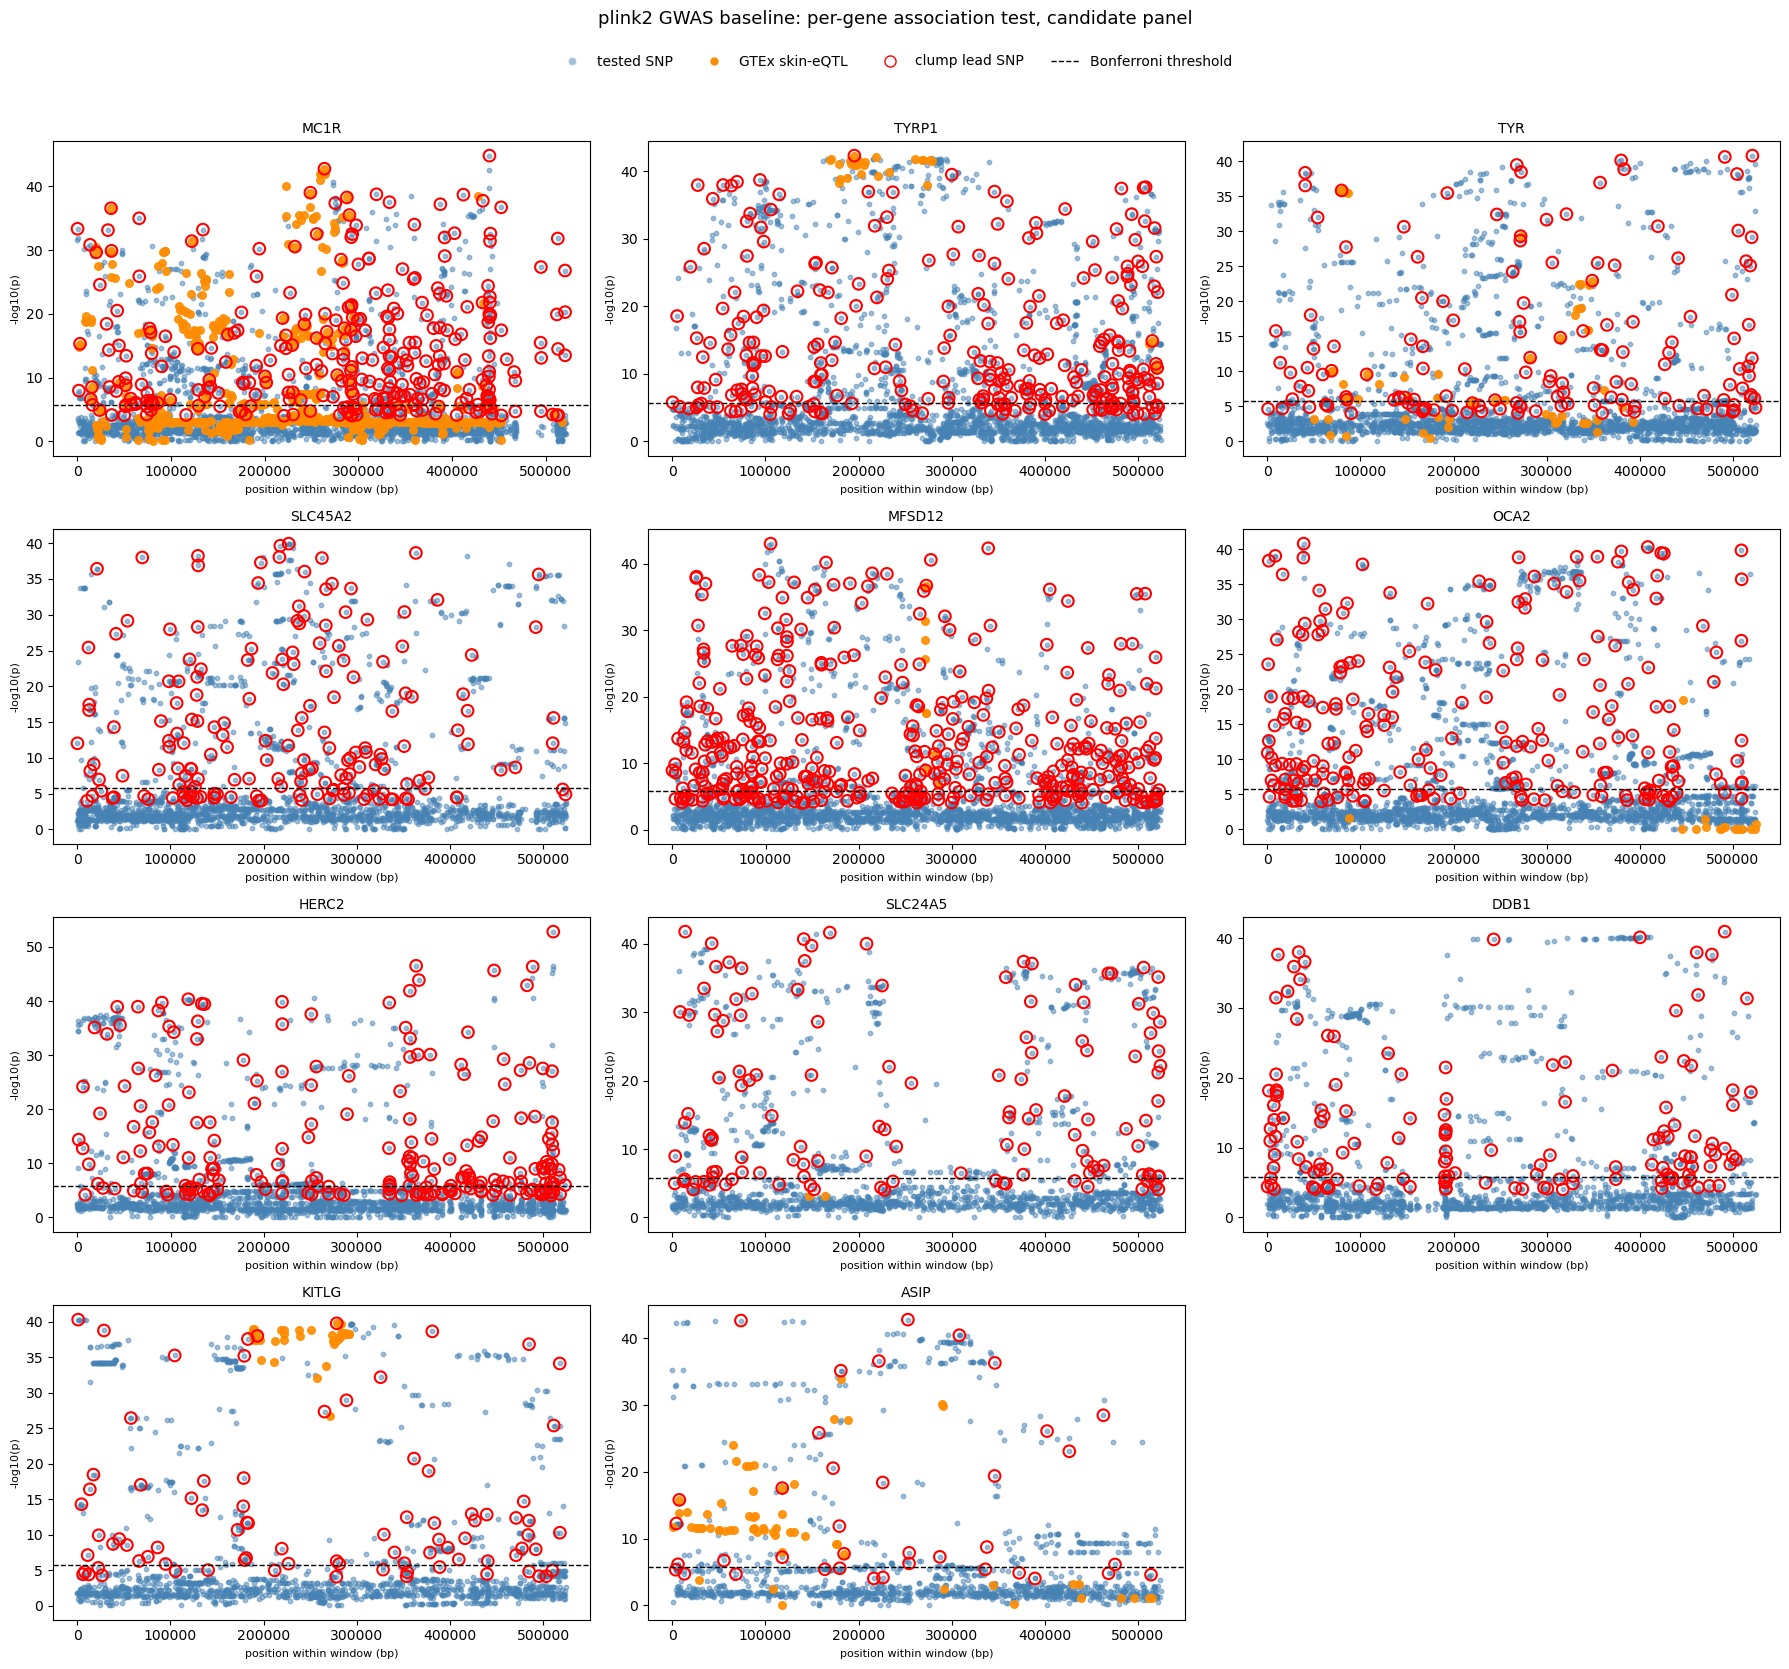

In [7]:
literature_by_gene = literature_variants.get_literature_variants_all_genes(
    GENES, windows_df, ctx.ANNOTATIONS_CACHE_DIR, top_n=None,
)
literature_positions_by_gene = {
    gene: {int(v.split(":")[1]) for v in df["variant"]} for gene, df in literature_by_gene.items()
}

bonferroni_line = -np.log10(bonferroni_p)
clumped_ids = set(clump_df["ID"]) if "ID" in clump_df.columns else set()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, gene in zip(axes, GENES):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    gene_snps = assoc_df[assoc_df["genes"].apply(lambda gs: gene in gs)]
    if gene_snps.empty:
        ax.set_title(f"{gene} (0 tested variants)", fontsize=10)
        ax.axis("off")
        continue

    rel_pos = gene_snps["POS"] - gene_data["start"]
    neglog10p = -np.log10(gene_snps["P"])
    is_lit = gene_snps["POS"].isin(literature_positions_by_gene.get(gene, set()))
    is_clumped = gene_snps["ID"].isin(clumped_ids)

    ax.scatter(rel_pos[~is_lit], neglog10p[~is_lit], s=10, color="steelblue", alpha=0.5)
    ax.scatter(rel_pos[is_lit], neglog10p[is_lit], s=30, color="darkorange", alpha=0.9)
    if is_clumped.any():
        ax.scatter(
            rel_pos[is_clumped], neglog10p[is_clumped], s=70, facecolors="none",
            edgecolors="red", linewidth=1.5,
        )
    ax.axhline(bonferroni_line, color="black", linestyle="--", linewidth=1)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("position within window (bp)", fontsize=8)
    ax.set_ylabel("-log10(p)", fontsize=8)

for ax in axes[len(GENES):]:
    ax.axis("off")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", alpha=0.5, markersize=6, label="tested SNP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange", markersize=7, label="GTEx skin-eQTL"),
    Line2D([0], [0], marker="o", color="w", markeredgecolor="red", markerfacecolor="none", markersize=8, label="clump lead SNP"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Bonferroni threshold"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("plink2 GWAS baseline: per-gene association test, candidate panel", y=1.04, fontsize=13)
fig.tight_layout()
plt.show()


## How to read the results above

Per the caveat at the top of this notebook: because phenotype is defined by population
membership, a gene showing *every* tested variant as Bonferroni-significant is showing the
expected signature of AFR/EUR allele-frequency differentiation across that whole region, not
necessarily a fine-mapped causal signal -- check the "Multiple testing correction" cell's warning
above, and treat the *clumped* lead-SNP table as the more informative summary than the raw
per-variant hit count (clumping collapses each correlated haplotype block to one signal, which is
a better proxy for "how many independent loci does this gene actually contribute" than a raw
Bonferroni-significant count that scales with local LD block size). A clumped lead SNP that also
coincides with a GTEx skin-eQTL (orange points above) is the closest thing this baseline has to
convergent evidence with the rest of this notebook series; a gene with zero tested variants
post-QC, or zero clumped hits, should be reported as such (not silently omitted) when comparing
against the AlphaGenome-based classifiers in `05_evaluation.ipynb`.
